
# Simple CNN from Scratch (Pure NumPy)

Convolutional Neural Network (CNN) entirely from scratch.
We have subset the CIFAR-10 dataset to just 3 classes (Bird, Cat, Dog) for faster training under these constraints.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# Set stable seed for reproducible results
np.random.seed(42)


## 1. Data Loading (Subset CIFAR-10)
We load the subset of CIFAR-10 containing images of birds, cats, and dogs. 
The images are read, resized to 32x32, normalized to `0.0 - 1.0`, and transposed to `(Channels, Height, Width)` format which aligns perfectly with sliding over 2D spatial dimensions.


X_train shape: (3000, 3, 32, 32) | Y_train_enc shape: (3000, 3)
X_test shape:  (600, 3, 32, 32)  | Y_test_enc shape:  (600, 3)


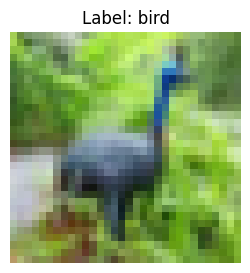

In [2]:

def load_cifar_subset(base_dir):
    categories = ['bird', 'cat', 'dog']
    X, y = [], []
    for label, category in enumerate(categories):
        folder = os.path.join(base_dir, category)
        if not os.path.exists(folder):
            print(f"Directory not found: {folder}. Skipping.")
            continue
        for file in os.listdir(folder):
            filepath = os.path.join(folder, file)
            try:
                img = Image.open(filepath).convert('RGB')
                img = img.resize((32, 32))
                img = np.array(img).astype(np.float32) / 255.0
                
                # Transpose from (H, W, C) to (C, H, W) for convolutions
                img = np.transpose(img, (2, 0, 1))
                X.append(img)
                y.append(label)
            except Exception as e:
                pass
    return np.array(X), np.array(y)


X_train, y_train = load_cifar_subset('cifar10/train')
X_test, y_test = load_cifar_subset('cifar10/test')

# One-hot encode the 3 classes
def one_hot_encode(y, num_classes=3):
    return np.eye(num_classes)[y]

Y_train_enc = one_hot_encode(y_train, 3)
Y_test_enc = one_hot_encode(y_test, 3)


print(f"X_train shape: {X_train.shape} | Y_train_enc shape: {Y_train_enc.shape}")
print(f"X_test shape:  {X_test.shape}  | Y_test_enc shape:  {Y_test_enc.shape}")

# Visualize a sample image
if len(X_train) > 0:
    plt.figure(figsize=(3, 3))
    img_show = np.transpose(X_train[0], (1, 2, 0)) # Transpose back to (H,W,C) for plotting
    plt.imshow(img_show)
    plt.title(f"Label: {['bird', 'cat', 'dog'][y_train[0]]}")
    plt.axis('off')
    plt.show()



## 2. Core CNN Layers Implementation

We break our CNN down into modular Object-Oriented Layers. Each layer has a `forward()` computation step and a `backward()` gradient step.

### 2a. Convolutional Layer (Conv2D)
A convolution consists of sliding trainable filters across the image. Utilizing native Python loops for this over batches would take hours!
To drastically optimize this without resorting to memory-heavy `im2col` functions, we utilize `np.tensordot`. This elegantly condenses multi-dimensional channel/height/width summation into a single hyper-fast matrix multiplication per spatial step.


In [4]:

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.k = kernel_size
        self.s = stride
        self.p = padding
        
        # He numerical initialization optimized for ReLU
        self.W = np.random.randn(out_channels, in_channels, self.k, self.k) * np.sqrt(2.0 / (in_channels * self.k * self.k))
        self.b = np.zeros((out_channels,))
        
    def forward(self, X):
        self.X = X
        n, c, h, w = X.shape
        out_h = (h - self.k + 2 * self.p) // self.s + 1
        out_w = (w - self.k + 2 * self.p) // self.s + 1
        
        # Pad spatial dimensions for input
        self.X_pad = np.pad(X, ((0,0), (0,0), (self.p, self.p), (self.p, self.p)), mode='constant')
        out = np.zeros((n, self.out_channels, out_h, out_w))
        
        # Convolve cleanly via tensordot which maps elements to the exact dimension shapes faster than standard arrays
        for i in range(out_h):
            for j in range(out_w):
                X_slice = self.X_pad[:, :, i*self.s:i*self.s+self.k, j*self.s:j*self.s+self.k]
                out[:, :, i, j] = np.tensordot(X_slice, self.W, axes=([1,2,3], [1,2,3])) + self.b
                
        return out

    def backward(self, dZ, lr):
        # Apply the chain rule backward from the output maps to the filters
        n, out_c, out_h, out_w = dZ.shape
        
        db = np.sum(dZ, axis=(0, 2, 3))
        dW = np.zeros_like(self.W)
        dX_pad = np.zeros_like(self.X_pad)
        
        for i in range(out_h):
            for j in range(out_w):
                X_slice = self.X_pad[:, :, i*self.s:i*self.s+self.k, j*self.s:j*self.s+self.k]
                dZ_slice = dZ[:, :, i, j] # Gradient at the spatial step: (Batch, Filters)
                
                # Backpropagate weights and inputs elegantly handling the dimensions 
                dW += np.tensordot(dZ_slice, X_slice, axes=([0], [0]))
                dX_pad[:, :, i*self.s:i*self.s+self.k, j*self.s:j*self.s+self.k] += np.tensordot(dZ_slice, self.W, axes=([1], [0]))
                
        # Update weights inside the layer iteratively! (Simple Gradient Descent)
        self.W -= lr * dW / n
        self.b -= lr * db / n
        
        # Strip padding for the backward flowing signal reaching earlier layers
        if self.p > 0:
            return dX_pad[:, :, self.p:-self.p, self.p:-self.p]
        return dX_pad



### 2b. Max Pooling Layer (MaxPool2D)
Pooling downsamples the feature maps, reducing computational dimensions and introducing slight spatial translation invariance so the CNN generalizes better!


In [5]:

class MaxPool2D:
    def __init__(self, size=2, stride=2):
        self.size = size
        self.stride = stride

    def forward(self, X):
        self.X = X
        n, c, h, w = X.shape
        out_h = (h - self.size) // self.stride + 1
        out_w = (w - self.size) // self.stride + 1
        out = np.zeros((n, c, out_h, out_w))
        
        for i in range(out_h):
            for j in range(out_w):
                X_slice = X[:, :, i*self.stride:i*self.stride+self.size, j*self.stride:j*self.stride+self.size]
                out[:, :, i, j] = np.max(X_slice, axis=(2, 3))
        return out

    def backward(self, dZ, lr):
        n, c, out_h, out_w = dZ.shape
        dX = np.zeros_like(self.X)
        
        for i in range(out_h):
            for j in range(out_w):
                X_slice = self.X[:, :, i*self.stride:i*self.stride+self.size, j*self.stride:j*self.stride+self.size]
                
                # Provide gradients purely back to the specific element that was the Maximum!
                max_vals = np.max(X_slice, axis=(2, 3), keepdims=True)
                mask = (X_slice == max_vals)
                
                # To prevent gradient doubling if there is an exact tie, we average the gradient across identical cells
                num_maxes = np.sum(mask, axis=(2, 3), keepdims=True)
                mask = mask / np.maximum(num_maxes, 1e-10)
                
                dX[:, :, i*self.stride:i*self.stride+self.size, j*self.stride:j*self.stride+self.size] += mask * dZ[:, :, i, j, None, None]
                
        return dX



### 2c. Flatten and Dense (Fully Connected) Layers
`Flatten` unravels 3D grid filters mapping into a flat 1D vector. `Dense` networks finish the calculation, outputting final class probabilities.


In [6]:

class Flatten:
    def forward(self, X):
        self.X_shape = X.shape
        return X.reshape(X.shape[0], -1)
    
    def backward(self, dZ, lr):
        return dZ.reshape(self.X_shape)

class Dense:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2. / in_features)
        self.b = np.zeros((1, out_features))

    def forward(self, X):
        self.X = X
        return np.dot(X, self.W) + self.b

    def backward(self, dZ, lr):
        # We calculate average weight slopes across the batch M
        m = self.X.shape[0]
        dW = np.dot(self.X.T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        dX = np.dot(dZ, self.W.T) # Flows raw gradient downwards
        
        # update rule
        self.W -= lr * dW
        self.b -= lr * db
        return dX



### 2d. Activation & Loss Functions
We utilize `ReLU` inside the blocks and `SoftmaxCrossEntropy` on the final probabilities to measure classification loss perfectly.


In [7]:

class ReLU:
    def forward(self, X):
        self.X = X
        # Zeros out anything subzero
        return np.maximum(0, X)
    
    def backward(self, dZ, lr):
        # Kills gradients traveling backward across non-activated paths
        return dZ * (self.X > 0)

class SoftmaxCrossEntropy:
    def forward(self, X, y_true):
        # Subtract max for floating-point calculation safety!
        exps = np.exp(X - np.max(X, axis=1, keepdims=True))
        self.probs = exps / np.sum(exps, axis=1, keepdims=True)
        self.y_true = y_true
        
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(self.probs + 1e-15)) / m
        return self.probs, loss
        
    def backward(self):
        # The derivation of Loss w.r.t logits for CategoricalCrossEntropy is wildly simple
        return self.probs - self.y_true



## 3. Assembling the Custom CNN Architecture

Our network connects the layers into a powerful visual hierarchy:
- **Block 1**: `Conv2D(8 filters) -> ReLU -> MaxPool2D`
- **Block 2**: `Conv2D(16 filters) -> ReLU -> MaxPool2D`
- **Head**: `Flatten -> Dense(32) -> ReLU -> Dense(3)`

Parameter counts is low to keep purely-NumPy loop times efficient.


In [8]:

class CustomCNN:
    def __init__(self):
        self.layers = [
            # Conv Block 1
            Conv2D(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1),
            ReLU(),
            MaxPool2D(size=2, stride=2),
            
            # Conv Block 2
            Conv2D(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1),
            ReLU(),
            MaxPool2D(size=2, stride=2),
            
            # Classifier
            Flatten(),
            Dense(in_features=16 * 8 * 8, out_features=32),
            ReLU(),
            Dense(in_features=32, out_features=3)
        ]
        self.loss_fn = SoftmaxCrossEntropy()
        
    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out
        
    def backward(self, lr):
        # Initializing the backpropagation algorithm with cross-entropy slopes
        dZ = self.loss_fn.backward()
        for layer in reversed(self.layers):
            dZ = layer.backward(dZ, lr)
            
    def train(self, X, Y, epochs=10, batch_size=32, lr=0.01):
        m = X.shape[0]
        history = {'loss': []}
        
        for epoch in range(epochs):
            # Dynamic shuffling prevents bias clustering
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation]
            Y_shuffled = Y[permutation]
            
            epoch_loss = 0
            num_batches = m // batch_size
            if num_batches == 0:
                num_batches = 1
                
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]
                
                # 1. Forward
                y_pred = self.forward(X_batch)
                _, loss = self.loss_fn.forward(y_pred, Y_batch)
                epoch_loss += loss
                
                # 2. Backward
                self.backward(lr)
            
            total_loss = epoch_loss / num_batches
            history['loss'].append(total_loss)
            
            # Print feedback to user every epoch
            print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {total_loss:.4f}")
                
        return history
        
    def predict(self, X):
        logits = self.forward(X)
        exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs = exps / np.sum(exps, axis=1, keepdims=True)
        return np.argmax(probs, axis=1)

    def evaluate(self, X, y_true):
        # Batch evaluation for larger datasets to prevent memory errors
        predictions = []
        batch_eval = 64
        for i in range(0, len(X), batch_eval):
            batch_predictions = self.predict(X[i:i+batch_eval])
            predictions.extend(batch_predictions)
            
        predictions = np.array(predictions)
        acc = np.mean(predictions == y_true)
        return acc, predictions



## 4. Execution: Training our Native CNN Model
We'll execute the native optimization framework! A standard pass through 3000 images will comfortably finish in a few minutes without a GPU.


In [ ]:

# Model instantiation
cnn = CustomCNN()

history = cnn.train(X_train, Y_train_enc, epochs=20, batch_size=64, lr=0.05)
print("Training Completed Succesfully!")


Initiating Native Gradient Descent Training Process...
Epoch  1/20 | Loss: 1.1146
Epoch  2/20 | Loss: 1.0593
Epoch  3/20 | Loss: 1.0207
Epoch  4/20 | Loss: 0.9914
Epoch  5/20 | Loss: 0.9522
Epoch  6/20 | Loss: 0.9464
Epoch  7/20 | Loss: 0.9192
Epoch  8/20 | Loss: 0.8828
Epoch  9/20 | Loss: 0.8837
Epoch 10/20 | Loss: 0.8592
Epoch 11/20 | Loss: 0.8411
Epoch 12/20 | Loss: 0.8377
Epoch 13/20 | Loss: 0.8164
Epoch 14/20 | Loss: 0.7934
Epoch 15/20 | Loss: 0.7906
Epoch 16/20 | Loss: 0.7717
Epoch 17/20 | Loss: 0.7475
Epoch 18/20 | Loss: 0.7384
Epoch 19/20 | Loss: 0.6960
Epoch 20/20 | Loss: 0.7086
Training Completed Succesfully!



## 5. Evaluation and Verification

Training Accuracy:  62.30%
Testing Accuracy:   51.33%


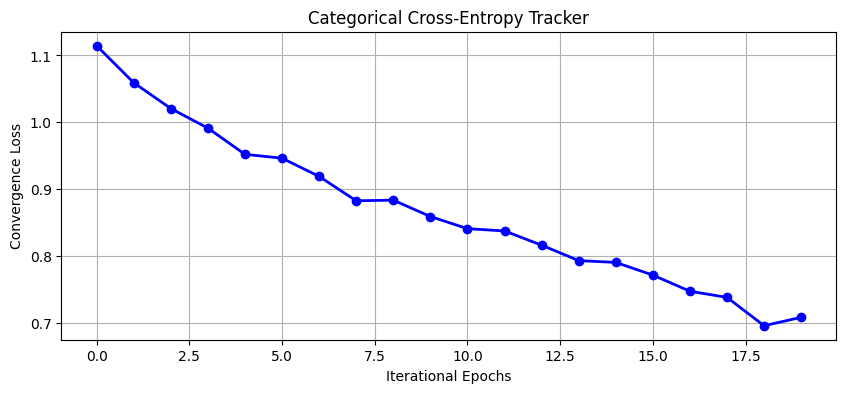


--- Model Interpretations on Unseen Test Dataset (Bird, Cat, Dog) ---


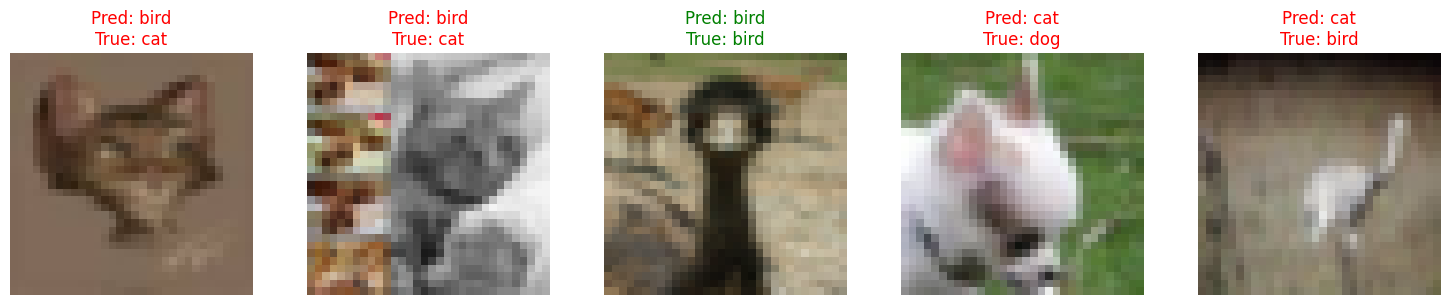

In [10]:

train_acc, _ = cnn.evaluate(X_train, y_train)
test_acc, y_pred_test = cnn.evaluate(X_test, y_test)

print(f"Training Accuracy:  {train_acc * 100:.2f}%")
print(f"Testing Accuracy:   {test_acc * 100:.2f}%")

# -- 1. Loss Tracker Plot
plt.figure(figsize=(10, 4))
plt.plot(history['loss'], color='blue', linewidth=2, marker='o')
plt.title('Categorical Cross-Entropy Tracker')
plt.xlabel('Iterational Epochs')
plt.ylabel('Convergence Loss')
plt.grid(True)
plt.show()

# -- 2. Random Visual Forecasts
print("\n--- Model Interpretations on Unseen Test Dataset (Bird, Cat, Dog) ---")
categories = ['bird', 'cat', 'dog']
num_visualize = 5
if len(X_test) > 0:
    random_indices = np.random.choice(len(X_test), num_visualize, replace=False)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(random_indices):
        plt.subplot(1, num_visualize, i + 1)
        
        # Reproject format visually
        img = np.transpose(X_test[idx], (1, 2, 0))
        true_label = categories[y_test[idx]]
        pred_label = categories[y_pred_test[idx]]
        
        plt.imshow(img)
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
